Anaconda 명령어    
conda env list    
conda remove -n aivle_tf --all    
1. aivle 이름의 Python 3.8 환경 생성    
conda create -n aivle_tf python=3.8 -y

2. 가상 환경 활성화        
conda activate aivle_tf    

3. 텐서플로 설치    
pip install tensorflow-gpu==2.10.0    
    
4. 파이토치
conda install pytorch==1.12.1 torchvision==0.13.1 torchaudio==0.12.1 cudatoolkit=11.3 -c pytorch

5. 기타 패키지 설치    
conda install matplotlib seaborn scikit-learn -y    
pip install lightgbm xgboost    

cuda_11.2.0_460.89_win10
cudnn-windows-x86_64-8.9.7.29_cuda12-archive

# 파이썬 버전

In [9]:
!python --version

Python 3.8.20


# TensorFlow 버전

## TF GPU동작 확인 및 CUDA, cuDNN 확인

In [1]:
import tensorflow as tf
import numpy as np

print("=== TensorFlow GPU 확인 테스트 ===")

# TensorFlow 버전 출력
print("TensorFlow version:", tf.__version__)

# 사용 가능한 GPU 장치 확인
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU detected! ✅")
    for i, gpu in enumerate(gpus):
        print(f"GPU {i} Name: {gpu.name}")
        details = tf.config.experimental.get_device_details(gpu)
        print(f"  Device name: {details.get('device_name', 'Unknown')}")
        print(f"  Compute capability: {details.get('compute_capability', 'Unknown')}")
else:
    print("No GPU found ❌ CPU만 사용됩니다.")

# CUDA & cuDNN 버전 확인
build_info = tf.sysconfig.get_build_info()
print("CUDA version:", build_info.get("cuda_version", "Unknown"))
print("cuDNN version:", build_info.get("cudnn_version", "Unknown"))
print("Is CUDA build:", build_info.get("is_cuda_build", False))

=== TensorFlow GPU 확인 테스트 ===
TensorFlow version: 2.10.0
GPU detected! ✅
GPU 0 Name: /physical_device:GPU:0
  Device name: NVIDIA GeForce RTX 3070 Ti
  Compute capability: (8, 6)
CUDA version: 64_112
cuDNN version: 64_8
Is CUDA build: True


In [2]:
a = tf.constant([[1, 2],
                 [3, 4]], dtype=tf.float32)
b = tf.constant([[5, 6],
                 [7, 8]], dtype=tf.float32)

c = tf.matmul(a, b)
print("Result of matrix multiplication:\n", c.numpy())

# 간단한 신경망 예제
x = np.random.rand(10, 3).astype(np.float32)
y = np.random.rand(10, 2).astype(np.float32)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation='relu', input_shape=(3,)),
    tf.keras.layers.Dense(2)
])

model.compile(optimizer='adam', loss='mse')
model.fit(x, y, epochs=2)

Result of matrix multiplication:
 [[19. 22.]
 [43. 50.]]
Epoch 1/2
1/1 [==============================] - 0s 264ms/step - loss: 0.5912
Epoch 2/2
1/1 [==============================] - 0s 3ms/step - loss: 0.5838


# PyTorch 버전

## PyTorch GPU 및 CUDA, cuDNN확인

In [3]:
import torch
print("=== PyTorch GPU 확인 테스트 ===")

# CUDA 사용 가능 여부
if torch.cuda.is_available():
    print("GPU detected! ✅")
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
    print("cuDNN version:", torch.backends.cudnn.version())
    print("Number of GPUs:", torch.cuda.device_count())
else:
    print("No GPU found ❌ CPU만 사용됩니다.")

=== PyTorch GPU 확인 테스트 ===
GPU detected! ✅
GPU name: NVIDIA GeForce RTX 3070 Ti
CUDA version: 11.3
cuDNN version: 8302
Number of GPUs: 1


## CPU vs GPU 속도 비교

In [4]:
import torch
import time

print("=== PyTorch GPU 성능 테스트 ===")

# GPU 사용 가능 여부
if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)} ✅")
else:
    print("No GPU detected ❌")

# 간단한 텐서 연산 (CPU vs GPU)
x = torch.rand((10000, 10000))
y = torch.rand((10000, 10000))

# CPU 연산
start = time.time()
_ = torch.mm(x, y)
print(f"CPU time: {time.time() - start:.4f} sec")

# GPU 연산
if torch.cuda.is_available():
    x_gpu = x.to('cuda')
    y_gpu = y.to('cuda')
    torch.cuda.synchronize()
    start = time.time()
    _ = torch.mm(x_gpu, y_gpu)
    torch.cuda.synchronize()
    print(f"GPU time: {time.time() - start:.4f} sec")


=== PyTorch GPU 성능 테스트 ===
GPU detected: NVIDIA GeForce RTX 3070 Ti ✅
CPU time: 12.5019 sec
GPU time: 0.5578 sec


# 시각화 함수

## Matplot 테스트

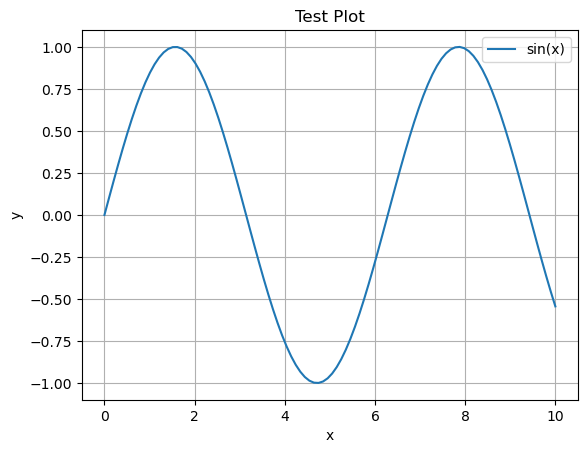

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 생성
x = np.linspace(0, 10, 100)
y = np.sin(x)

# 그래프 그리기
plt.plot(x, y, label="sin(x)")
plt.title("Test Plot")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

# 그래프 표시
plt.show()


## Seabron 테스트

=== Seaborn Test ===


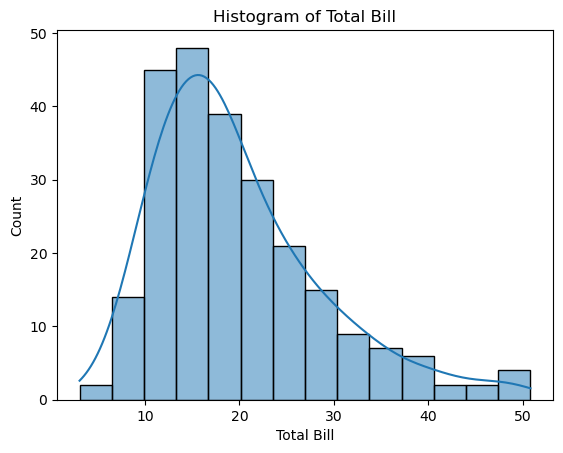

Seaborn is working correctly! ✅


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

print("=== Seaborn Test ===")

# 예제 데이터셋 로드
tips = sns.load_dataset("tips")  # 식당 팁 데이터셋

# 간단한 히스토그램 그리기
sns.histplot(tips['total_bill'], kde=True)
plt.title("Histogram of Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Count")
plt.show()

print("Seaborn is working correctly! ✅")